<a href="https://colab.research.google.com/github/cam2149/icesi-nlp/blob/Entrega4/Entrega4V4_13092025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**UNIVERSIDAD ICESI**
# **MAESTRÍA EN INTELIGENCIA ARTIFICIAL APLICADA**  
## **Trabajo 4: Clasificación de Texto con BERT y Hugging Face**

### Integrantes:
- Diego Agudelo  
- Angelica Maria Mayor  
- Freddy Mauricio Gutierrez  
- Carlos Alberto Martinez Ramirez  
- Wilman Quiñonez  

---

# Clasificación de Texto con BERT y Hugging Face  

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/cam2149/icesi-nlp/blob/Entrega4/Sesion4/Entrega4.ipynb)

En este notebook implementaremos un clasificador de noticias de Colombia en español utilizando **Transformers**, basándonos en un modelo pre-entrenado tipo **BERT (Bidirectional Encoder Representation from Transformers)** disponible en **Hugging Face Hub**.  

El propósito de esta tarea es aprender a utilizar **modelos pre-entrenados** que, de entrenarse desde cero, serían sumamente costosos tanto en poder de cómputo como en disponibilidad de datos. Gran parte de la labor ya ha sido realizada, y nuestra tarea será **especializar el modelo en la clasificación de texto en español**.  

En esta ocasión, nos apartaremos de **PyTorch Lightning** y haremos uso extensivo de las herramientas de **Hugging Face**, diseñadas para este tipo de tareas, incluyendo la interacción con modelos pre-entrenados.  

---

## Descripción General

En este trabajo exploraremos la **clasificación de texto en ingles** utilizando arquitecturas de tipo **Transformers**, en particular modelos pre-entrenados disponibles en **Hugging Face Hub**.  

El objetivo es **entrenar y evaluar clasificadores ingles** aplicados a dos dominios distintos:  

1. Noticias en español (dataset de noticias colombianas).  
2. Reseñas de productos en e-commerce (dataset de reseñas de zapatos en Amazon).  

---

## Estructura del Dataset de Reseñas

El dataset de zapatos de Amazon contiene reseñas de clientes con información variada sobre productos, usuarios y el propio texto de la reseña. La siguiente tabla resume cada columna:  

| Columna             | Descripción                                                                 |
|---------------------|-----------------------------------------------------------------------------|
| `marketplace`       | País donde se realizó la reseña (ej. US).                                   |
| `customer_id`       | Identificador anónimo del cliente.                                          |
| `review_id`         | ID único de la reseña.                                                      |
| `product_id`        | Código del producto en Amazon (ASIN).                                       |
| `product_parent`    | Identificador que agrupa variaciones del producto.                          |
| `product_title`     | Nombre del producto reseñado.                                               |
| `product_category`  | Categoría general (en este dataset: Shoes).                                 |
| `category`          | Subcategoría codificada en valores numéricos (0, 1, 2, 3).                  |
| `helpful_votes`     | Número de votos de utilidad recibidos por la reseña.                        |
| `total_votes`       | Votos totales recibidos.                                                    |
| `vine`              | Indica si pertenece al programa Vine de Amazon (0 = no, 1 = sí).            |
| `verified_purchase` | Indica si la compra fue verificada (1) o no (0).                            |
| `review_headline`   | Título de la reseña.                                                        |
| `text`              | Texto completo de la reseña.                                                |
| `review_date`       | Fecha de publicación de la reseña.                                          |

---

#### Referencias
- Dataset: https://huggingface.co/datasets/Censius-AI/ECommerce-Women-Clothing-Reviews
- [BETO: Spanish BERT](https://huggingface.co/datasets/Censius-AI/ECommerce-Women-Clothing-Reviews)
- [BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding](http://arxiv.org/abs/1810.04805)
- [Natural Language Processing with Transformers: Building Language Applications With Hugging Face](https://www.amazon.com/Natural-Language-Processing-Transformers-Applications/dp/1098103246)
- [Hugging Face Transformers](https://huggingface.co/docs/transformers/v4.41.3/en/index)
- [Hugging Face Accelerate](https://huggingface.co/docs/accelerate/index)
- [Hugging Face Evaluate](https://huggingface.co/docs/evaluate/v0.4.0/en/index)
- [Hugging Face Datasets](https://huggingface.co/docs/datasets/v2.19.0/en/index)

In [57]:
import pkg_resources
import warnings

warnings.filterwarnings('ignore')

installed_packages = [package.key for package in pkg_resources.working_set]
IN_COLAB = 'google-colab' in installed_packages

In [58]:
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [59]:
#!test '{IN_COLAB}' = 'True' && wget  https://github.com/Ohtar10/icesi-nlp/raw/refs/heads/main/requirements.txt && pip install -r requirements.txt
!test '{IN_COLAB}' = 'True' && sudo apt-get update -y
# Si la variable IN_COLAB es True (se está en Google Colab), entonces
# actualiza la lista de paquetes disponibles en los repositorios de Ubuntu.
# 'sudo' eleva permisos para instalación/configuración del sistema.
# '-y' confirma automáticamente sin preguntar.

!test '{IN_COLAB}' = 'True' && sudo apt-get install python3.10 python3.10-distutils python3.10-lib2to3 -y
# Si en Colab, instala Python 3.10 y dos paquetes relacionados necesarios para
# herramientas de desarrollo y compatibilidad (distutils, lib2to3).
# '-y' para confirmar instalación sin interrupciones.

!test '{IN_COLAB}' = 'True' && sudo update-alternatives --install /usr/local/bin/python python /usr/bin/python3.11 2
# Si en Colab, registra Python 3.11 en el manejador de alternativas para 'python',
# asignándole prioridad 2 (más alta), linking para control de versión python.

!test '{IN_COLAB}' = 'True' && sudo update-alternatives --install /usr/local/bin/python python /usr/bin/python3.10 1
# Si en Colab, registra también Python 3.10 en el manejador de alternativas para 'python',
# con menor prioridad 1. Esto permite alternar fácilmente entre versiones de Python.

!test '{IN_COLAB}' = 'True' && pip install lightning datasets 'transformers[torch]' sentence-transformers torchinfo evaluate optuna
# Si en Colab, instala con pip varias librerías Python necesarias para procesamiento,
# entrenamiento y evaluación de modelos de NLP y deep learning:
# lightning (framework de entrenamiento), datasets (datasets HuggingFace),
# transformers (modelos preentrenados con PyTorch), sentence-transformers,
# torchinfo (resumen modelo), evaluate (métricas).
# Added optuna for hyperparameter optimization.

Hit:1 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 https://cli.github.com/packages stable InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:6 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading packag

In [60]:
import torch

# Verificar si hay GPU disponible y definir el dispositivo
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando dispositivo: {device}")

Usando dispositivo: cuda


### Cargando el dataset
## Descripción del Dataset de Reseñas de Zapatos

Este es un dataset de reseñas de productos de **calzado en Amazon** en idioma inglés, con información sobre clientes, productos y opiniones escritas. El dataset está disponible en el **Hugging Face Hub** y puede ser fácilmente descargado con la librería `datasets`.

- **train**: 90k registros  
- **test**: 5k registros  
- **valid**: 5k registros  



In [61]:
import pkg_resources
import warnings
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import optuna  # Optimización automática de hiperparámetros mediante búsquedas eficientes (Bayesian, TPE, etc.)
from optuna.importance import get_param_importances
import optuna.visualization as vis
from datasets import load_dataset


warnings.filterwarnings("ignore")
# Cargar el dataset ECommerce-Women-Clothing-Reviews
print("Cargando dataset de ECommerce-Women-Clothing-Reviews...")
dataset = load_dataset('prashantgrao/amazon-shoe-reviews', split='train')

# Set the format to pandas and then rename the column
dataset.set_format(type="pandas")
dataset = dataset.rename_column('labels', 'category')

df = dataset.to_pandas()
print("Estructura del dataset:")
print(df)
print("\nEjemplo de muestra:")
display(df.head())

Cargando dataset de ECommerce-Women-Clothing-Reviews...
Estructura del dataset:
      marketplace customer_id       review_id  product_id product_parent  \
0              US    47360648   RDGHV08I3LECC  B01138BGOG      271105500   
1              US    15209903   RG9AROFTEYGZQ  B001IV5BW2      743402566   
2              US     8312582  R3EWFP6VQ8XOI3  B00CSIA1UQ      785011863   
3              US    41599887  R2BAMPF5U9MLSB  B00QFKN95M      937852017   
4              US    45664084  R320SOSDM7SAXI  B00E1BZZUE      520424777   
...           ...         ...             ...         ...            ...   
89995          US    29816649  R2EO9T7ZBB4UJ9  B00MOP34L6      642859205   
89996          US    32802546  R3VVUI29YPMI4L  B004VQW3WC      172828759   
89997          US    10914713   RC03AJTBLBMK4  B00HHZ2XUG      180179571   
89998          US    39820013   R7FLWP4GC7O6G  B00VXP48Z4       70995602   
89999          US    44065928  R2H1VG1PWF1OSW  B004LPEJ5W      256491827   

       

,marketplace,customer_id,review_id,product_id,product_parent,product_title,product_category,category,helpful_votes,total_votes,vine,verified_purchase,review_headline,text,review_date
0,US,47360648,RDGHV08I3LECC,B01138BGOG,271105500,Alpine Swiss Men's Lucerne Slip On Loafers,Shoes,3,1,1,0,1,Four Stars,Good shoe for office work. They will scuff ver...,2015-08-23
1,US,15209903,RG9AROFTEYGZQ,B001IV5BW2,743402566,Crocs Women's Patricia Miniwedge Sandal,Shoes,1,3,4,0,0,Patricia vs Patricia II shoe Patricia II is a...,I have had the Patricia II wedge in black for ...,2015-07-10
2,US,8312582,R3EWFP6VQ8XOI3,B00CSIA1UQ,785011863,Mizuno Women's Wave Prophecy 3 Running Shoe,Shoes,1,0,0,0,1,... little wider and ordered size larger would...,Width not right and size too small if width ha...,2015-08-24
3,US,41599887,R2BAMPF5U9MLSB,B00QFKN95M,937852017,Nike Men's Free 5.0 Running Shoe,Shoes,0,3,5,0,1,Bad service,I received these shoes and they weren't the sa...,2015-07-23
4,US,45664084,R320SOSDM7SAXI,B00E1BZZUE,520424777,Reebok Women's Sublite Duo Instinct Running Shoe,Shoes,2,0,0,0,1,... split alone the mesh material after a mont...,They began to split alone the mesh material af...,2015-08-08


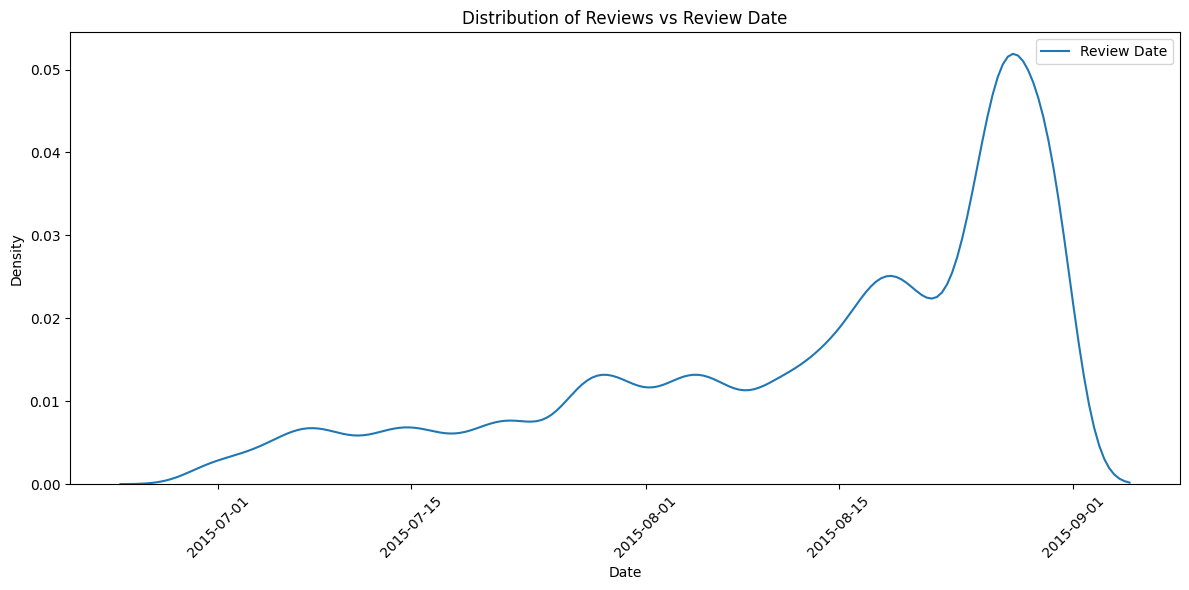

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert date columns to datetime objects (already done in previous cell, but good practice to include)
df['review_date'] = pd.to_datetime(df['review_date'], errors='coerce')

plt.figure(figsize=(12, 6))

# Plot the distribution of news_init_date as a line plot
sns.kdeplot(df['review_date'].dropna(), label='Review Date')

plt.title('Distribution of Reviews vs Review Date')
plt.xlabel('Date')
plt.ylabel('Density')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [63]:
import pandas as pd
import plotly.express as px

# Asegura datetime
df['review_date'] = pd.to_datetime(df['review_date'], errors='coerce')

# Histograma como aproximación de densidad
fig = px.histogram(
    df.dropna(subset=['review_date']),
    x='review_date',
    nbins=60,  # ajusta según rango/granularidad
    histnorm='probability density',
    title='Distribution of Reviews vs Review Date'
)
fig.update_traces(marker_line_width=0)
fig.update_layout(
    xaxis_title='Date',
    yaxis_title='Density',
    bargap=0.01
)
fig.show()


La gráfica muestra que al inicio de julio de 2015 casi no había reseñas, pero con el paso de las semanas fueron aumentando de manera gradual hasta llegar a un pico muy alto a finales de agosto, cuando se concentró la mayor cantidad de reseñas. Después de ese punto, la cantidad de reseñas cayó rápidamente en los primeros días de septiembre.

In [64]:
# Ordenar el DataFrame por la longitud del contenido de 'news_title' en orden descendente
df = df.sort_values(by='text', key=lambda x: x.str.len(), ascending=False).reset_index(drop=True)

En esta ocasión, vamos a explorar un poco más las características del dataset a manera ilustrativa.

Primero, observemos la distribución de las clases:

In [65]:


# Conteos ascendentes por categoría
vc = df['category'].value_counts(ascending=True)
data = vc.rename_axis('category').reset_index(name='count')

fig = px.bar(
    data, x='count', y='category',
    orientation='h',
    title='Distribución de categorías de clases',
    text='count'
)

# Mantener el orden ascendente en el eje Y
fig.update_layout(yaxis=dict(categoryorder='array', categoryarray=data['category']))
fig.update_traces(textposition='outside', cliponaxis=False)
fig.show()


Las cinco categorías están prácticamente balanceadas, cada una con alrededor del 20% del total. No hay una categoría que destaque mucho más que las demás.

In [66]:
# Contar la cantidad de ocurrencias de cada categoría en la columna 'labels'
print(df.category.value_counts())

category
4    18044
2    18039
0    18004
1    17980
3    17933
Name: count, dtype: int64


In [67]:
import numpy as np

# Crear un diccionario que asocia IDs únicos a cada categoría en 'df['category']'
id2category = dict(enumerate(np.unique(df['category'])))
# Invertir el diccionario anterior para crear un mapeo de categoría a ID
category2id = {v: k for k, v in id2category.items()}

# Añadir una nueva columna 'category_id' al DataFrame que contiene el ID asociado a cada categoría
df['category_id'] = df['category'].apply(lambda x: category2id[x])
# Reordenar las columnas del DataFrame y mezclar aleatoriamente las filas
df = df[['text', 'category', 'category_id']].sample(frac=1).reset_index(drop=True)

print("Distribución de categorías actualizada:")
print(df.category.value_counts())
print("\nMapeo actualizado de id2category:")
display(id2category)
print("\nMapeo actualizado de category2id:")
display(category2id)

Distribución de categorías actualizada:
category
4    18044
2    18039
0    18004
1    17980
3    17933
Name: count, dtype: int64

Mapeo actualizado de id2category:


{0: np.int64(0),
 1: np.int64(1),
 2: np.int64(2),
 3: np.int64(3),
 4: np.int64(4)}


Mapeo actualizado de category2id:


{np.int64(0): 0,
 np.int64(1): 1,
 np.int64(2): 2,
 np.int64(3): 3,
 np.int64(4): 4}

In [68]:
# Mostrar las primeras filas del DataFrame
print(df.head())

                                                text  category  category_id
0                                               good         2            2
1  They are the right colors and really affordabl...         0            0
2  Plastic looking; strap broke off; extremely ch...         0            0
3  Great walking shoes. Love that they are mostly...         3            3
4    Returned them - they run at least a size small.         0            0


#### Ahora observemos la dispersión de las palabras por cada categoría.

In [69]:
import pandas as pd
import plotly.express as px

# Columna de longitud (palabras por texto)
df['Palabras por Texto'] = df['text'].fillna('').str.split().str.len()

# Boxplot por categoría (sin outliers)
fig = px.box(
    df,
    x='category',
    y='Palabras por Texto',
    points=False,          # equivalente a showfliers=False
    title=''               # mismo que plt.suptitle('')
)

# Estilo: bordes negros, sin relleno y sin grilla
fig.update_traces(line_color='blue', fillcolor='rgba(0,0,0,0)')
fig.update_xaxes(showgrid=False, title_text='')  # mismo que plt.xlabel('')
fig.update_yaxes(showgrid=False, title_text='Palabras por Texto')

# Tamaño aproximado a (16, 8)
fig.update_layout(width=1000, height=1000, showlegend=False)

fig.show()


En el total de 90,000 textos, la longitud típica es de 20 palabras (mediana), con un promedio de 33.34 y desviación estándar de 43.04, lo que indica mucha dispersión y una clara asimetría a la derecha (promedio > mediana). El 10% más corto tiene ≤3 palabras y el 90% supera 78, con un máximo extremo de 1,676 palabras; es decir, hay bastantes textos muy largos que estiran la cola de la distribución.

Por categoría, el volumen está equilibrado (~18k por clase). Las clases con textos más largos son 1 (media 38.40, mediana 25), 2 (36.07, 23) y 0 (35.78, 22); 3 queda intermedia (32.34, 19) y 4 es la más breve (24.12, 12). En los percentiles altos, la clase 1 alcanza el p90=87 (más extensa), seguida por 0 (82), 2 (81), 3 (76) y 4 (59). El máximo más extremo aparece en 2 (1,676 palabras), consistente con la presencia de outliers y la cola larga observada.

In [70]:
print(df.groupby('category')['Palabras por Texto'].median())

category
0    22.0
1    25.0
2    23.0
3    19.0
4    12.0
Name: Palabras por Texto, dtype: float64


In [71]:
# Restablecer el formato del dataset a su estado original o eliminar cualquier formato personalizado
dataset.reset_format()

Asegura que el texto queda libre de etiquetas HTML y enlaces web, listo para tareas de análisis o modelado NLP.

* Se utiliza re.sub(r'<.*?>', '', text) para quitar todas las etiquetas HTML del contenido.

* Se emplea re.sub(r'http[s]?://\S+', '', text) para eliminar enlaces web.

* Se conservan signos de puntuación básicos y se eliminan caracteres especiales innecesarios.

In [72]:
import re
from bs4 import BeautifulSoup

def clean_text(example):
    """
    Limpia el texto de entrada quitando etiquetas HTML, enlaces HTTP/HTTPS,
    caracteres especiales y espacios innecesarios.

    Args:
        example (dict): Diccionario con la clave 'news_text_content'.

    Returns:
        dict: El mismo diccionario con el texto limpio en 'news_text_content'.
    """
    text = example['text']
    # Elimina saltos de línea y retornos de carro
    text = text.replace('\n', ' ').replace('\r', ' ')
    # Eliminar etiquetas HTML
    text = BeautifulSoup(text, "html.parser").get_text()
    # Elimina etiquetas HTML
    text = re.sub(r'<.*?>', '', text)
    # Elimina enlaces que inician por http o https
    text = re.sub(r'http[s]?://\S+', '', text)
    # Elimina signos de puntuación no relevantes (conservando algunos)
    text = re.sub(r'[^\w\s.,!?;()\[\]"\'-]', '', text)
    # Reemplaza múltiples espacios por uno solo
    text = re.sub(r'\s+', ' ', text).strip()
    example['text'] = text
    return example

# Aplica la función de limpieza al campo 'news_text_content' usando dataset.map()
dataset = dataset.map(clean_text)


In [73]:
dataset

Dataset({
    features: ['marketplace', 'customer_id', 'review_id', 'product_id', 'product_parent', 'product_title', 'product_category', 'category', 'helpful_votes', 'total_votes', 'vine', 'verified_purchase', 'review_headline', 'text', 'review_date'],
    num_rows: 90000
})

In [74]:
# Select the desired columns from the dataset
dataset = dataset.select_columns(['text', 'category'])

# Shuffle the dataset
dataset = dataset.shuffle(seed=42)

# Display the first few rows of the updated dataset
print("Conjunto de datos con columnas seleccionadas:")
display(dataset.to_pandas().head())

Conjunto de datos con columnas seleccionadas:


,text,category
0,It's July 19th and I received these shoes Apri...,0
1,Returned as there were deep scratches on the b...,0
2,I have tons of Crocs in tons of styles and siz...,1
3,very comfortable,4
4,Nice,3


Implementamos una estrategia de eliminación de stopwords (palabras vacías) en español usando la biblioteca NLTK para preprocesamiento de texto del dataset

In [75]:
import nltk
from nltk.corpus import stopwords

# Descargue la lista de palabras vacías en español si aún no la ha descargado
try:
    stopwords.words('english')
except LookupError:
    nltk.download('stopwords')

english_stopwords = set(stopwords.words('english'))

def remove_stopwords(example):
    """
    Elimina las palabras vacías del contenido del texto.

    Argumentos:
    ejemplo (dict): Diccionario con la clave 'text'.

    Devuelve:
    dict: El mismo diccionario con las palabras vacías eliminadas de 'text'.

    """
    text = example['text']
    words = text.split()
    filtered_words = [word for word in words if word.lower() not in english_stopwords]
    example['text'] = ' '.join(filtered_words)
    return example

# Aplique la función de eliminación de palabras vacías al campo 'text' usando dataset.map()
dataset = dataset.map(remove_stopwords)

print("Conjunto de datos después de eliminar las palabras vacías:")
print(dataset)

Conjunto de datos después de eliminar las palabras vacías:
Dataset({
    features: ['text', 'category'],
    num_rows: 90000
})


In [76]:
dataset

Dataset({
    features: ['text', 'category'],
    num_rows: 90000
})

## **Modelo Baseline**



Se desarrollo un modelo baseline, de regresion y clasificacion con el fin de tener un estimado del ajuste de un modelo inicial

In [77]:
# ====== BASELINES RÁPIDOS: TF-IDF + Clasificación/Regresión ======
import numpy as np, pandas as pd, random, warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    mean_absolute_error, mean_squared_error, r2_score
)
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, Ridge

# ------------------ CONFIG ------------------
RANDOM_STATE = 42
TEST_SIZE = 0.2  # 80/20
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

# ------------------ DATAFRAME ------------------
# Usa 'dataset' (HF Dataset) si existe; si no, asume que ya tienes 'df' en memoria.
try:
    dataset  # si existe un objeto Dataset llamado 'dataset'
    df = dataset.to_pandas()
except NameError:
    assert 'df' in globals(), "Define 'dataset' (HF Dataset) o 'df' (pandas DataFrame)."

assert {'text','category'}.issubset(df.columns), "df debe tener columnas 'text' y 'category'"
df = df[['text','category']].copy()
df['text'] = df['text'].fillna('').astype(str)

# ------------------ LABELS & SPLIT ------------------
le = LabelEncoder()
y = le.fit_transform(df['category'])  # 0..K-1

X_train, X_test, y_train, y_test = train_test_split(
    df['text'], y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"[INFO] Clases ({len(le.classes_)}): {list(le.classes_)}")
print(f"[INFO] Train: {len(X_train)}, Test: {len(X_test)}")

# ------------------ TF-IDF + LOGISTIC REGRESSION (CLASIFICACIÓN) ------------------
tfidf_clf = Pipeline([
    ('tfidf', TfidfVectorizer(
        min_df=2,
        ngram_range=(1,2),
        max_features=100_000,
        token_pattern=r'(?u)\b\w\w+\b'
    )),
    ('clf', LogisticRegression(max_iter=1000, n_jobs=-1, class_weight='balanced'))
])

tfidf_clf.fit(X_train, y_train)
y_pred_tfidf = tfidf_clf.predict(X_test)

print("\n== TF-IDF + LogReg (Clasificación) ==")
print("Accuracy:", round(accuracy_score(y_test, y_pred_tfidf), 4))
print("F1-macro:", round(f1_score(y_test, y_pred_tfidf, average='macro'), 4))
print(classification_report(y_test, y_pred_tfidf, target_names=[str(c) for c in le.classes_]))

# ------------------ TF-IDF + RIDGE (REGRESIÓN SOBRE IDs DE CLASE) ------------------
tfidf_reg = Pipeline([
    ('tfidf', TfidfVectorizer(
        min_df=2,
        ngram_range=(1,2),
        max_features=100_000,
        token_pattern=r'(?u)\b\w\w+\b'
    )),
    ('reg', Ridge(alpha=1.0, random_state=RANDOM_STATE))
])

tfidf_reg.fit(X_train, y_train.astype(float))
y_pred_reg = tfidf_reg.predict(X_test)

y_true_f = y_test.astype(float)
mae = mean_absolute_error(y_true_f, y_pred_reg)

# Compatibilidad con versiones de sklearn sin el parámetro 'squared'
try:
    rmse = mean_squared_error(y_true_f, y_pred_reg, squared=False)
except TypeError:
    rmse = np.sqrt(mean_squared_error(y_true_f, y_pred_reg))

r2 = r2_score(y_true_f, y_pred_reg)

# Accuracy aproximada redondeando al ID más cercano
y_pred_round = np.rint(y_pred_reg).clip(0, len(le.classes_)-1).astype(int)
acc_approx = accuracy_score(y_test, y_pred_round)

print("\n== TF-IDF + Ridge (Regresión sobre IDs) ==")
print("MAE:", round(mae, 4))
print("RMSE:", round(rmse, 4))
print("R2:", round(r2, 4))
print("Accuracy aprox (redondeada):", round(acc_approx, 4))


[INFO] Clases (5): [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
[INFO] Train: 72000, Test: 18000

== TF-IDF + LogReg (Clasificación) ==
Accuracy: 0.5069
F1-macro: 0.5021
              precision    recall  f1-score   support

           0       0.56      0.61      0.58      3601
           1       0.40      0.37      0.39      3596
           2       0.42      0.38      0.40      3608
           3       0.47      0.45      0.46      3586
           4       0.64      0.72      0.68      3609

    accuracy                           0.51     18000
   macro avg       0.50      0.51      0.50     18000
weighted avg       0.50      0.51      0.50     18000


== TF-IDF + Ridge (Regresión sobre IDs) ==
MAE: 0.7286
RMSE: 0.9229
R2: 0.5744
Accuracy aprox (redondeada): 0.4297


Con TF-IDF + Regresión Logística, el modelo alcanza 51% de accuracy y F1-macro 0.50 en un test de 18,000 ejemplos balanceados. Rinde mejor en las clases 4 (P=0.64, R=0.72, F1=0.68) y 0 (F1=0.58), mientras que 1 y 2 presentan peor desempeño (F1≈0.39–0.40), indicando confusiones entre esas dos categorías.

Con TF-IDF + Ridge (regresión sobre IDs), obtiene MAE 0.73, RMSE 0.92, R² 0.57 y accuracy redondeada 0.43; es inferior a la clasificación directa

### Definiendo el Tokenizer

Como la idea en este notebook es la de re-utilizar modelos pre-entrenados, algo a tener en cuenta es que para que esto funcione correctamente, debemos **siempre** utilizar el mismo tokenizador que se usó para entrenar el modelo. Recordemos que el tokenizador asigna un código a cada token del vocabulario, y durante la creación de los embeddings, el modelo asume esto como entrada, por lo que su usamos otro tokenizador, el modelo va a ser incapaz de derivar las relaciones semánticas apropiadas.

Para esta tarea, haremos uso de un modelo BERT pre-entrenado en corpus del idioma español. El modelo puede ser encontrado [aquí](https://huggingface.co/dccuchile/bert-base-spanish-wwm-cased), es un modelo entrenado por el [Departamento de Ciencias de la Computación de la Universidad de Chile](https://www.dcc.uchile.cl), el cual según los autores, fue entrenado en un gran corpus de idioma español por lo que resulta un buen candidato para la tarea en cuestión.

Este código carga un tokenizador basado en BERT en español que ha sido entrenado con Whole Word Masking (WWM). Es útil para preparar datos de texto antes de alimentar modelos de transformers.

In [78]:
# Importar la clase AutoTokenizer de transformers para cargar el tokenizador preentrenado
from transformers import AutoTokenizer

# Especificar el nombre del modelo preentrenado en Hugging Face
model_ckpt = "bert-base-uncased"

# Cargar el tokenizador asociado al modelo preentrenado
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)


Ahora sometamos a prueba el tokenizador con la misma frase del notebook anterior.

Este bloque de código ajusta el token de padding y realiza una tokenización con relleno y truncamiento para que la secuencia tenga exactamente 10 tokens.



In [79]:
# Este código obtiene y muestra la cantidad total de tokens en el vocabulario del tokenizer.
# Establecer manualmente el token de padding del tokenizer a '[PAD]'
tokenizer.pad_token = '[PAD]'

# Tokenizar la secuencia "hola mundo!!" con un máximo de 10 tokens,
# truncando si es necesario, y rellenando hasta la longitud máxima
tokens = tokenizer("Hi world!!", max_length=10, truncation=True, padding='max_length').tokens()

# Mostrar los tokens resultantes
print(tokens)


['[CLS]', 'hi', 'world', '!', '!', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']


Algo interesante, este tokenizador, por lo menos para las palabras de esta frase de prueba, no separa en tokens distintos estas palabras, esto es justamente la razón por la cual no deberíamos usar un tokenizador diferente con un modelo pre-entrenado, habríamos obtenido tokens diferentes y el modelo no lograría interpretar la semantica como se espera.

Ahora, observemos su vocabulario.

In [80]:
# Obtener el tamaño del vocabulario del tokenizer
vocab_size = tokenizer.vocab_size

# Mostrar el tamaño del vocabulario
print(vocab_size)


30522


Tenemos $30522$ tokens, es una cantidad inferior que el modelo manual que intentamos en la lección anterior, pero lo suficientemente amplio para una tarea de NLP.

Ahora, observemos otros parámetros del tokenizador.

In [81]:
# Obtener la longitud máxima de la secuencia que el modelo puede procesar
model_max_length = tokenizer.model_max_length

# Mostrar la longitud máxima del modelo
print(model_max_length)


512


In [82]:
# Obtener los nombres de entrada que espera el tokenizer (generalmente ['input_ids', 'attention_mask'])
model_input_names = tokenizer.model_input_names

# Mostrar los nombres de las entradas del modelo
print(model_input_names)


['input_ids', 'token_type_ids', 'attention_mask']


Primero, observamos que el tokenizador por defecto maneja un tamaño de secuencia de $512$, convenientemente al rededor de la misma longitud mediana de nuestro dataset, por lo que resulta perfecto para nuestro caso de uso. Finalmente, observamos sus salidas, las cuales serán las entradas a nuestro modelo. Como ya debemos saber, `input_ids` son los indices de los tokens y `attention_mask` es la máscara de atención cuando tenemos tokens irrelevantes (como el padding) en la cadena.

## Usando un modelo BERT pre-entrenado sencillo

Primero, vamos a probar con un modelo pre-entrenado sin mayor modificación a la capa de clasificación. Hugging Face ofrece una clase utilitaria para inicializar el modelo en modo de clasificación de secuencias, lo cual hará que convenientemente tengamos una capa o cabeza de clasificación en el modelo, justo con la cantidad de clases que definamos.

Recordemos que el modelo y el tokenizador deben pertenecer al mismo "paquete", por lo que invocamos a `from_pretrained` con el mismo id que al tokenizer.

Técnicamente hay dos formas de utilizar un modelo pre-entrenado:

1. Como Featurizer: Es decir, vamos a utilizar todas las capas de codificación del modelo **sin re-entrenarlas** o lo que sería lo mismo **congelandolas** haciendo que lo único que vayamos a entrenar sea el clasificador en si.
2. Fine Tuning: Es decir, dejar todas las capas entrenables y entrenar el modelo en su totalidad, a partir del checkpoint del modelo pre-entrenado, para nuestra tarea especifica.



### BERT pre-entrenado como featurizer (simple)

Una ventaja de este enfoque es que es menos costoso de entrenar, a nivel de recursos de computo, ya que no vamos a calcular gradientes para todas las capas sino para la capa de clasificación. Incluso, no es necesario que utilicemos deep learning para la clasificación final, podemos usar algoritmos clasicos, que parten de los embeddings producidos por el modelo pre-entrenado.

Otra ventaja es que debido a que puede ser mucho más rápido de entrenar que no solo un modelo desde cero, sino más rápido que fine tuning, nuevamente, porque ya no es necesario calcular gradientes para todo el modelo, sino solo para la capa de clasificación de nuestro interes.

In [83]:
import torch
from torchinfo import summary
from transformers import AutoModelForSequenceClassification

# Seleccionar el dispositivo: GPU si está disponible, sino CPU
device = "cuda" if torch.cuda.is_available() else "cpu"

# Tokenizar la entrada "hola mundo!!!"
# con máximo de 10 tokens, truncar si excede, rellenar hasta la longitud máxima y devolver tensores PyTorch
inputs = tokenizer(
    "Hi world!!!",
    max_length=10,
    truncation=True,
    padding='max_length',
    return_tensors='pt'
)

# Mostrar las formas y tipos de datos de los tensores de entrada
print(f"Input Shapes & Types:")
print({k: (v.shape, v.dtype) for k, v in inputs.items()})

# Cargar el modelo de clasificación de secuencias preentrenado y ajustarlo para nuevo número de clases
model = AutoModelForSequenceClassification.from_pretrained(
    model_ckpt,
    num_labels=len(category2id)
).to(device)

# Congelar los pesos del modelo base para que solo se ajusten las capas finales, usándolo como extractor de características
for param in model.base_model.parameters():
    param.requires_grad = False

# # Definir el tamaño y el tipo de entrada para el resumen
# # Como el modelo espera un batch, replicamos la forma de la entrada tres veces
input_sizes = [inputs['input_ids'].shape] * 3
input_types = [inputs['input_ids'].dtype] * 3

# # Realizar un resumen del modelo en modo evaluación sin calcular gradientes
with torch.no_grad():
    print(
        summary(
            model,
            input_size=input_sizes,
            dtypes=input_types,
            col_names=['input_size', 'output_size', 'num_params', 'trainable']
        )
    )

Input Shapes & Types:
{'input_ids': (torch.Size([1, 10]), torch.int64), 'token_type_ids': (torch.Size([1, 10]), torch.int64), 'attention_mask': (torch.Size([1, 10]), torch.int64)}


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Layer (type:depth-idx)                                       Input Shape               Output Shape              Param #                   Trainable
BertForSequenceClassification                                [1, 10]                   [1, 5]                    --                        Partial
├─BertModel: 1-1                                             [1, 10]                   [1, 768]                  --                        False
│    └─BertEmbeddings: 2-1                                   --                        [1, 10, 768]              --                        False
│    │    └─Embedding: 3-1                                   [1, 10]                   [1, 10, 768]              (23,440,896)              False
│    │    └─Embedding: 3-2                                   [1, 10]                   [1, 10, 768]              (1,536)                   False
│    │    └─Embedding: 3-3                                   [1, 10]                   [1, 10, 768]              (393,216)  

Observamos que el modelo tiene una capa `BertModel` que corresponde al modelo pre-entrenado y finaliza con una capa lineal que sería nuestro clasificador, esta es una capa proporcionada para nosotros al momento de inicializar el modelo. Además, observamos que solamente la capa lineal que hemos especificado tiene parámetros entrenables. Entonces, a pesar de que el modelo en si tiene más de 100 millones de parámetros `[109,856,263]`, solamente menos de 10 mil son entrenables `[5,383]`.

Observemos todos los modulos registrados en el modelo:

In [84]:
# Obtener la lista de todos los módulos del modelo usando 'named_modules()'
# Esto devuelve un iterador de (nombre, módulo), y se extraen solo los módulos
modules = [m for m, _ in model.named_modules()]

# Mostrar la lista de módulos
modules


['',
 'bert',
 'bert.embeddings',
 'bert.embeddings.word_embeddings',
 'bert.embeddings.position_embeddings',
 'bert.embeddings.token_type_embeddings',
 'bert.embeddings.LayerNorm',
 'bert.embeddings.dropout',
 'bert.encoder',
 'bert.encoder.layer',
 'bert.encoder.layer.0',
 'bert.encoder.layer.0.attention',
 'bert.encoder.layer.0.attention.self',
 'bert.encoder.layer.0.attention.self.query',
 'bert.encoder.layer.0.attention.self.key',
 'bert.encoder.layer.0.attention.self.value',
 'bert.encoder.layer.0.attention.self.dropout',
 'bert.encoder.layer.0.attention.output',
 'bert.encoder.layer.0.attention.output.dense',
 'bert.encoder.layer.0.attention.output.LayerNorm',
 'bert.encoder.layer.0.attention.output.dropout',
 'bert.encoder.layer.0.intermediate',
 'bert.encoder.layer.0.intermediate.dense',
 'bert.encoder.layer.0.intermediate.intermediate_act_fn',
 'bert.encoder.layer.0.output',
 'bert.encoder.layer.0.output.dense',
 'bert.encoder.layer.0.output.LayerNorm',
 'bert.encoder.layer.0

Observamos que la capa final es efectivamente el `classifier`. Ahora hagamos una prueba pasando un dummy input:

In [85]:
# Ejecutar el bloque sin calcular gradientes, ya que estamos en modo evaluación
with torch.no_grad():
    # Mover los tensores de entrada al dispositivo (GPU o CPU)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    # Realizar la inferencia pasándoles los datos al modelo
    outputs = model(**inputs)

# Mostrar las formas de los tensors en el diccionario de salida del modelo
print({k: v.shape for k, v in outputs.items()})


{'logits': torch.Size([1, 5])}


In [86]:
# La variable 'outputs' contiene el resultado de la inferencia del modelo
# Para un modelo de clasificación de secuencias, típicamente incluye:
# - logits: las puntuaciones antes de aplicar la función softmax
# - (opcionalmente) otras salidas como loss si se proporcionan etiquetas durante entrenamiento
#
# Imprimir 'outputs' mostrará un diccionario con estos tensores, ej:
# {'logits': tensor(...), ...}
print(outputs)  # Diccionario con las salidas del modelo: 'logits' (tensor [batch_size, num_labels]) y, si está habilitado, 'hidden_states' y 'attentions'


SequenceClassifierOutput(loss=None, logits=tensor([[ 0.5631,  0.1446, -0.1466, -0.5220, -0.1795]], device='cuda:0'), hidden_states=None, attentions=None)


In [87]:
# Acceder a la capa 'classifier' del modelo, que generalmente es la capa final de clasificación
model.classifier # Capa de clasificación final (nn.Linear) que transforma la representación pooled en logits de tamaño num_labels


Linear(in_features=768, out_features=5, bias=True)

Observamos que tras invocar el modelo, en efecto, obtenemos una salida de `[7]` dimensiones, correspondientes al número de clases.

Ahora preparemos los datos para el entrenamiento.

Hugging Face Datasets convenientemente implementa una función para hacer el train-test splig en nuestro dataset y automáticamente creará nuevas llaves en el mismo para diferenciarlo.

In [88]:
# Dividir el dataset original en conjunto de entrenamiento (80%) y conjunto de prueba (20%)

#training_dataset = dataset.train_test_split(train_size=0.8) # Crea un split: 80% train y 20% test a partir del dataset original

# Desde el conjunto de prueba generado anteriormente, dividir en validación y prueba
# La mitad del conjunto de test (que ahora es el 20% inicial) se usará para validación
#validation_dataset = training_dataset['test'].train_test_split(train_size=0.5)




In [89]:
# Divide el dataset original para hacer uso del 30% de los datos
# Usamos train_size=0.3 para tomar el 30% del dataset original para el split inicial
training_validation_dataset = dataset.train_test_split(train_size=0.3, seed=42)

# Desde el conjunto de entrenamiento/validacion generado anteriormente (que es el 30% del original),
# dividir en entrenamiento (80% de ese 20%) y validacion (50% de ese 20%)
# La mitad del conjunto de test (que ahora es el 20% inicial) se usará para validación
training_dataset = training_validation_dataset['train'].train_test_split(train_size=0.8, seed=42)
validation_dataset = training_dataset['test'].train_test_split(train_size=0.5, seed=42) # El 20% restante del 30% original es para prueba

In [90]:
# Importar la clase DatasetDict del módulo datasets.dataset_dict
from datasets.dataset_dict import DatasetDict

# Crear un nuevo DatasetDict con los conjuntos de entrenamiento, validación y prueba
new_dataset = DatasetDict({
    'train': training_dataset['train'],         # Conjunto de entrenamiento (80% original)
    'val': validation_dataset['train'],         # Conjunto de validación (10% original)
    'test': validation_dataset['test'],         # Conjunto de prueba (10% original)
})

# Mostrar el DatasetDict resultante
# Ahora tenemos:
# - training_dataset['train']: 80% del dataset original para entrenamiento
# - validation_dataset['train']: 10% del dataset original para validación
# - validation_dataset['test']: 10% del dataset original para pruebas (si quieres usarlo)


Tenemos nuestros tres conjuntos, sin embargo, esto es la información cruda, debemos preparar los datos para el modelo, lo gual incluye tokenizar y convertir las categorías a ids. Preparamos entonces unas funciones utilitarias.

In [91]:
def preprocess_function(max_len):                         # Devuelve una función que tokeniza ejemplos usando max_len
    def _preprocess_function(examples):                   # Función interna que recibe ejemplos (puede ser batch)
        return tokenizer(examples['text'],   # Tokeniza el campo 'news_text_content'
                         max_length=max_len,              # Longitud máxima fija
                         truncation=True,                 # Trunca si supera max_len
                         padding='max_length')            # Rellena hasta max_len
    return _preprocess_function                           # Retorna la función preparada

def tokenize(max_len: int = 8):                           # Devuelve una función para tokenizar batches (longitud por defecto 8)
    def _tokenize(batch):                                 # Función interna que opera sobre un batch
        return tokenizer(batch['text'],      # Tokeniza el campo 'news_text_content' del batch
                         max_length=max_len,              # Longitud máxima
                         truncation=True,                 # Truncamiento activado
                         padding='max_length')            # Padding hasta max_len
    return _tokenize                                      # Retorna la función de tokenización

def category_names_2_ids(batch):                          # Convierte nombres de categoría a IDs numéricos en el batch
    batch['label'] = category2id[batch['category']]       # Asigna columna 'label' usando el mapping category2id
    return batch

Y procedemos a invocarlas. Nótese que para la tokenización, estamos forzando a que las cadenas sean de 512 tokens, según el análisis que hemos hecho anteriormente.

In [92]:
# Aplicar la función de preprocesamiento a todo el dataset en modo batch,
# limitando la longitud de las secuencias a 512 tokens
tokenized_dataset = new_dataset.map(preprocess_function(max_len=512), batched=True)

# Mapear las categorías a IDs en todo el dataset usando la función definida anteriormente
tokenized_dataset = tokenized_dataset.map(category_names_2_ids)

# Mostrar el dataset tokenizado y con las categorías convertidas a IDs
tokenized_dataset


Map:   0%|          | 0/21600 [00:00<?, ? examples/s]

Map:   0%|          | 0/2700 [00:00<?, ? examples/s]

Map:   0%|          | 0/2700 [00:00<?, ? examples/s]

Map:   0%|          | 0/21600 [00:00<?, ? examples/s]

Map:   0%|          | 0/2700 [00:00<?, ? examples/s]

Map:   0%|          | 0/2700 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'category', 'input_ids', 'token_type_ids', 'attention_mask', 'label'],
        num_rows: 21600
    })
    val: Dataset({
        features: ['text', 'category', 'input_ids', 'token_type_ids', 'attention_mask', 'label'],
        num_rows: 2700
    })
    test: Dataset({
        features: ['text', 'category', 'input_ids', 'token_type_ids', 'attention_mask', 'label'],
        num_rows: 2700
    })
})

#### Entrenamiento

Ahora procederemos al entrenamiento. Aquí harémos uso de las API de HuggingFace directamente.

In [93]:
from transformers import AutoModelForSequenceClassification
from transformers import Trainer, TrainingArguments
from typing import Dict, Any
import evaluate

# Cargar la métrica de precisión 'accuracy' para evaluar el rendimiento del modelo
accuracy = evaluate.load("accuracy")

# Definir una función que calcula y retorna métricas de evaluación (precisión en este caso)
def compute_metrics(pred) -> Dict[str, Any]:
    """compute metrics

    Esta función será invocada en cada época durante el entrenamiento
    y se usará para calcular la métrica de calidad del modelo.
    """
    # Obtener las etiquetas verdaderas
    labels = pred.label_ids
    # Obtener las predicciones y seleccionar la clase con mayor puntuación
    preds = pred.predictions.argmax(-1)
    # Calcular la precisión comparando las predicciones con las etiquetas reales
    acc = accuracy.compute(predictions=preds, references=labels)
    # Retornar la métrica en forma de diccionario
    return acc

# Definir el tamaño de batch dependiendo del entorno (Colab o local)
batch_size = 8 if IN_COLAB else 4

# Calcular cuántos pasos de logging habrá en cada época
logging_steps = len(tokenized_dataset['train']) // batch_size


In [94]:

# Definir los argumentos de entrenamiento, como duración, tasa de aprendizaje, batch size, etc.
training_args = TrainingArguments(
    output_dir='./hf',                      # Directorio para modelos y logs
    num_train_epochs=3,                     # Número de épocas de entrenamiento
    learning_rate=2e-5,                     # Tasa de aprendizaje
    per_device_eval_batch_size=batch_size, # Batch size para evaluación
    per_device_train_batch_size=batch_size,# Batch size para entrenamiento
    weight_decay=0.01,                      # Decaimiento del peso para regularización
    eval_strategy='epoch',                  # Evaluación al final de cada época
    save_strategy='epoch',                  # Guardar al final de cada época
    load_best_model_at_end=True,            # Cargar el mejor modelo al final
    disable_tqdm=False,                     # Mostrar barra de progreso
    logging_steps=logging_steps,            # Pasos entre logs
    report_to='tensorboard'                 # No reportar a wandb u otro tracker
)


# Crear un objeto Trainer con el modelo, args, datasets, tokenizador y métrica
trainer = Trainer(
    model=model,                        # Modelo a entrenar
    args=training_args,                 # Argumentos de entrenamiento
    compute_metrics=compute_metrics,   # Función para calcular métricas
    train_dataset=tokenized_dataset['train'],  # Dataset de entrenamiento
    eval_dataset=tokenized_dataset['val'],     # Dataset de validación
    tokenizer=tokenizer                 # Tokenizador utilizado
)

Con esto nos basta para ejecutar el entrenamiento:

In [ ]:
%%time
trainer.train()

Epoch,Training Loss,Validation Loss


Se entrenó un clasificador de texto basado en BERT usando la librería Hugging Face, evaluado con accuracy en un conjunto de validación. Tras 3 épocas (≈8100 pasos), el modelo alcanzó ~29% de accuracy con una pérdida de validación ~1.58: un resultado superior al azar (≈20% si hay cinco clases) pero aún modesto, lo que sugiere subajuste

In [ ]:
%load_ext tensorboard

In [ ]:
%tensorboard --logdir hf/runs

Y ahora evaluemos el modelo en el conjunto de prueba:

In [ ]:
model.eval()
trainer.evaluate(tokenized_dataset['test'])

Hemos alcanzado una correctitud del $\approx 30\%$,
### Haciendo uso del modelo
Ahora, hagamos predicciónes con el modelo y observemos los resultados.

In [ ]:
predictions = trainer.predict(tokenized_dataset['test'])
predictions

In [ ]:
predicted_labels = np.argmax(predictions.predictions, axis=-1)
test_set = tokenized_dataset['test']
test_set = test_set.add_column('prediction_label', predicted_labels)
test_set = test_set.add_column('prediction', list(map(lambda label: id2category[label], predicted_labels)))
test_set

In [ ]:
columns = ['text', 'prediction_label', 'category', 'prediction']
test_set.set_format('pandas', columns=columns)
df = test_set.to_pandas()[columns]
df.style.set_table_styles(
    [
        {'selector': 'td', 'props': [('word-wrap', 'break-word')]}
    ]
)
df.head(15)

Los resultados no lucen nada mal, aún se cometen un par de errores, pero de resto, parece bastante aceptable. Observemos los errores.

In [ ]:
errors = df[df['category'] != df['prediction']]
errors.head(15)

In [ ]:
# Calculate the number of errors
num_errors = len(errors)

# Calculate the total number of samples in the test set
total_samples = len(df)

# Calculate the error percentage
error_percentage = (num_errors / total_samples) * 100

# Print the number of errors and the error percentage
print(f"Number of errors: {num_errors}")
print(f"Error percentage: {error_percentage:.2f}%")

El  porcnetaje de error es del 69.81 %, o cual indica que debemos seguir iterando para llegar a un valor mas alto.

## Usando una capa más especializada como clasificador

Quizás podemos hacerlo mejor, hemos observado que por defecto, cuando cargamos la clase, Hugging Face nos da un clasificador muy simple, solo una capa lineal. Pero podemos utilizar un clasificador más complejo que definamos nosotros. Esta técnica seguiría utilizando el resto del modelo como featurizer, pero ahora añadimos complejidad a la capa de clasificación en búsqueda de una mejor calidad en los resutlados.

Entonces, volvemos a cargar el modelo tal como hemos hecho antes:

In [ ]:
# Cargar el modelo de clasificación de secuencias usando un checkpoint preentrenado.
# 'model_ckpt' es el nombre del modelo de HuggingFace (por ejemplo, bert-base-uncased).
# Se especifica 'num_labels' para que el modelo adapte la cabeza de clasificación al número de categorías.
# El modelo se mueve al dispositivo de cómputo correcto (GPU o CPU).
model = AutoModelForSequenceClassification.from_pretrained(model_ckpt, num_labels=len(category2id)).to(device)

# Congelar todos los parámetros del modelo base (por ejemplo, el encoder de BERT).
# Esto significa que durante el entrenamiento, solo se actualizarán los parámetros de las capas superiores (la cabeza de clasificación).
for param in model.base_model.parameters():
    param.requires_grad = False

# Preparar las especificaciones para inspeccionar el modelo con la función summary.
# Se crean listas con el tamaño ('shape') y el tipo de datos ('dtype') de los inputs,
# Aquí se asume que 'inputs["input_ids"]' representa la entrada principal del modelo.
input_sizes = [inputs['input_ids'].shape] * 3
input_types = [inputs['input_ids'].dtype] * 3

# Mostrar un resumen de la arquitectura del modelo sin calcular gradientes (modo inferencia).
# Se imprime información sobre tamaños de entrada/salida, cantidad de parámetros y cuáles son entrenables.
with torch.no_grad():
    print(summary(
        model,
        input_size=input_sizes,
        dtypes=input_types,
        col_names=['input_size', 'output_size', 'num_params', 'trainable']
    ))


In [ ]:
model.classifier

### Definimos un clasificador propio

Podemos definir cualquier tipo de clasificador que se nos ocurra, siempre que se ajuste a las entradas y salidas del clasificador existente. Vamos a utilizar por ejemplo la misma capa lineal que definimos en el notebook anterior:

In [ ]:
import torch.nn as nn


classifier = nn.Sequential(
    nn.Linear(768, 512),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(256, len(category2id)), # Changed output size to match the number of categories
    nn.LogSoftmax(dim=1)
)

# simply reemplazamos el clasificador existente por el nuestro:
model.classifier = classifier
with torch.no_grad():
    print(summary(model, input_size=input_sizes, dtypes=input_types, col_names=['input_size', 'output_size', 'num_params', 'trainable']))

Observamos que nuestro modelo ya tiene más parámetros para entrenar, producto de nuestro nuevo clasificador.

Procedemos a definir nuevamente el entrenador.

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    compute_metrics=compute_metrics,
    train_dataset=tokenized_dataset['train'],
    eval_dataset=tokenized_dataset['val'],
    tokenizer=tokenizer
)

Y a entrenar el modelo

In [ ]:
%%time

trainer.train()

Y evaluamos el resultado:

In [ ]:
model.eval()
trainer.evaluate(tokenized_dataset['test'])

No hemos obtenidos una mejora significativa al modelo

## Fine Tuning con BERT

Para terminar, ahora harémos fine tuning, es decir, vamos a dejar libres todas las capas del modelo base para que todas calculen gradiente y entrenen sobre nuestra tarea específica.

En este caso entonces no necesitamos modificar nada del modelo original, podemos instanciarlo y proceder directamente al entrenamiento:

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(model_ckpt, num_labels=len(category2id)).to(device)
trainer = Trainer(
    model=model,
    args=training_args,
    compute_metrics=compute_metrics,
    train_dataset=tokenized_dataset['train'],
    eval_dataset=tokenized_dataset['val'],
    tokenizer=tokenizer
)

In [ ]:
%%time
trainer.train()

In [ ]:
model.eval()
trainer.evaluate(tokenized_dataset['test'])

Modelo

Hemos alcanzado una correctitud superior al $\approx 90\%$ en el conjunto de prueba!

Con fine tuning, todas las capas del modelo ajustarán sus parámetros en respuesta al proceso de entrenamiento, por lo que es natural que la calidad de los resultados se incremente significativamente. Sin embargo, no hay que abusar del fine tuning ya que tiende a hacer overfitting al conjunto con el que se entrena, por eso también es recomendable no entrenarlo demasiado.

## **Modelo Bert Regresión:**

In [ ]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    model_ckpt,
    num_labels=1,        # regresión = salida continua
    problem_type="regression"  # <- muy importante
).to(device)

def category_names_2_ids(batch):
    batch["labels"] = [float(s) for s in batch["category"]]
    return batch

In [ ]:
import evaluate
import numpy as np

mse_metric = evaluate.load("mse")

def compute_metrics(pred):
    preds = pred.predictions.squeeze()  # salida continua
    labels = pred.label_ids
    mse = mse_metric.compute(predictions=preds, references=labels)["mse"]
    rmse = np.sqrt(mse)
    return {"rmse": rmse, "mse": mse}

In [ ]:
tokenized_dataset = new_dataset.map(
    preprocess_function(max_len=90),
    batched=True
)

In [ ]:
tokenized_dataset = tokenized_dataset.map(
    category_names_2_ids,
    batched=True
)

In [ ]:
training_args = TrainingArguments(
    output_dir='./hf',
    num_train_epochs=2,
    learning_rate=2e-5,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    weight_decay=0.01,

    eval_strategy='epoch',   # <--- correcto
    save_strategy='epoch',
    load_best_model_at_end=False,
    save_total_limit=1,
    logging_steps=logging_steps,
    report_to='tensorboard',

    dataloader_pin_memory=True,
    dataloader_num_workers=4,
    optim="adamw_torch",
    fp16=torch.cuda.is_available(),  # opcional en GPU
)

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    compute_metrics=compute_metrics,
    train_dataset=tokenized_dataset['train'],
    eval_dataset=tokenized_dataset['val'],
    tokenizer=tokenizer,
    data_collator=data_collator,
)

In [ ]:
%%time
trainer.train()

In [ ]:
model.eval()
# Usar trainer para obtener predicciones
predictions = trainer.predict(tokenized_dataset["test"])
# Los labels reales
y_true = predictions.label_ids
# Los valores predichos (continous)
y_pred = predictions.predictions.squeeze()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=y_true, y=y_pred)
plt.xlabel("Observado (stars)")
plt.ylabel("Pronosticado (stars)")
plt.title("Distribución de predicciones por valor observado")
plt.show()

## Conclusiones
- Trabajar con modelos pre-entrenados supone una mejora no solo en la calidad de los resultados, sino en los tiempos de entrenamiento y esfuerzo requerido para la labor.
- En general, particularmente con modelos de lenguaje, dado lo costoso que puede resultar su entrenamiento desde cero, a día de hoy es mejor empezar con un modelo pre-entrenado y hacer bien transfer learning o fine tuning.
- Implementar modelos nuevos tiene sentido cuando la tarea en cuestión es particularmente novedosa o definitivamente no se cuenta con un modelo pre-entrenado que por lo menos capture parte del contexto requerido para la tarea. Ejemplos de esto puede ser una tarea en un idioma para el cual no exista aún un modelo fundacional, o que los existentes hayan sido entrenados en un corpus limitado o sesgado a un campo de dominio por ejemplo, ciertamente sería difícil obtener resultados de buena calidad para un modelo de clasificación en el ámbito legal, partiendo de un modelo entrenado exclusivamente en el ámbito clínico.
- Dentro de las posibilidades de usar un modelo pre-entrenado en forma de transfer learning o fine tuning, si fine tuning es superior, porque molestarse con las otras formas? porque no siempre se va a contar con los recursos (datos, computo y tiempo) para hacer fine tuning, o por ejemplo, en el runtime objetivo no se cuenta con GPU, por lo que quizás sea más factible usar modelos clásicos. Cada situación merece analizarse para hallar el mejor modo a implementar.